# DIP 数据加载与滤波示例

本 notebook 演示如何用现有 `ble_analysis` 模块处理 **Direct IQ Pipeline（DIP）** 采集的 JSONL 帧数据。

## DIP 与旧 CS 数据的主要区别

| 项目 | CS（Channel Sounding） | DIP（Direct IQ） |
|------|------------------------|------------------|
| `frame_type` | `channel_sounding` | `dip_direct_iq` |
| IQ 来源 | Local + Remote 均有 | **仅 Local**（`remote_*`、`ir`/`qr` 为 0） |
| 典型采样率 | ~1.5–2 Hz（稀疏跳频） | 设备侧可达 **~20 Hz 或更高 |
| 分析字段 | `local_amplitudes` / `remote_amplitudes` | 只用 **`local_amplitudes` / `phases`** |

## 推荐流程

1. 加载 JSONL → 2. 提取单通道 local IQ → 3. **用时间戳估计真实采样率**（勿写死）
4. 可选重采样到 20 Hz（便于复用 CS 呼吸带通参数）→ 5. `apply_filter_pipeline` 滤波 → 6. 绘图

Globecom 26 投稿相关的 CS/DF 分析见 `glb_*` 系列 notebook；本 notebook 属于 **DIP 项目**。


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# 环境引导：必须先把 src/ 加入 sys.path，再 import ble_analysis
# 无论从项目根目录还是 notebooks/ 下启动 Jupyter，这段代码都能自动定位项目根
# ------------------------------------------------------------------
_cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [_cwd, *_cwd.parents] if (p / "src").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("未找到项目根目录（缺少 src/ 目录）")

_src = project_root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from ble_analysis.bootstrap import init_notebook

# init_notebook 会创建 outputs/figures|processed|reports/ 并返回常用路径
_env = init_notebook(project_root)
project_root = _env["project_root"]
FIGURES_DIR = _env["FIGURES_DIR"]
PROCESSED_DIR = _env["PROCESSED_DIR"]
REPORTS_DIR = _env["REPORTS_DIR"]

print(f"项目根目录: {project_root}")
print(f"图表输出:   {FIGURES_DIR}")

项目根目录: D:\Work\atomic\ble_hci_sensing
图表输出:   D:\Work\atomic\ble_hci_sensing\outputs\figures


## 1. 参数配置

只需修改下面 cell 中的路径与通道号。`use_decimate_to_20hz` 控制是否在滤波前把信号降到 20 Hz——
若后续要对接 CS 分段呼吸脚本（`glb_cs_segment_breath_analysis.ipynb` 同款带通 0.1–0.35 Hz），建议开启。

In [15]:
# === 用户参数（仅改这里）===

# DIP JSONL 文件路径（请改为你自己的采集文件）
filepath = Path(r"c:\Users\cwdbo\Downloads\DIP_frames_all_20260519_165725.jsonl")

# 要分析的 BLE 信道编号（与帧内 channels[].channel 字段一致）
channel = 2

# True：先重采样到 20 Hz 再滤波（与 CS 呼吸算法参数尺度一致）
# False：在原始采样率上直接滤波（本示例文件约 1000 Hz，median/hampel 窗口需相应加大）
use_decimate_to_20hz = True
target_fs = 20.0  # 重采样目标频率（Hz），仅 use_decimate_to_20hz=True 时生效

if not filepath.exists():
    raise FileNotFoundError(
        f"找不到数据文件: {filepath}\n"
        "请修改 filepath 指向你的 DIP_frames_all_*.jsonl"
    )

## 2. 加载帧数据

`load_ble_frames` 内部调用 `DataSaver`，已支持 `DIP_` 前缀与 `dip_direct_iq` 帧类型，
无需为 DIP 单独写 loader。

In [16]:
from ble_analysis.data import load_ble_frames
from ble_analysis.channels import get_available_channels

data, frames = load_ble_frames(filepath)

print(f"frame_type : {data.get('frame_type')}")
print(f"版本       : {data.get('version')}")
print(f"总帧数     : {len(frames)}")
print(f"时间跨度   : {frames[-1]['timestamp_ms'] - frames[0]['timestamp_ms']} ms")

available = get_available_channels(frames)
print(f"出现过的通道数: {len(available)}，示例: {available[:10]}...")

if channel not in available:
    raise ValueError(f"通道 {channel} 不在数据中，请从 available 里选一个")

✓ 找到文件: c:\Users\cwdbo\Downloads\DIP_frames_all_20260519_165725.jsonl
文件大小: 39.41 MB
正在加载: c:\Users\cwdbo\Downloads\DIP_frames_all_20260519_165725.jsonl
✓ 加载成功
✓ 共加载 2621 帧数据
frame_type : dip_direct_iq
版本       : 3.6.0
总帧数     : 2621
时间跨度   : 2620 ms
出现过的通道数: 72，示例: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


## 3. 提取单通道 Local IQ

DIP 帧里每个 channel 条目包含 `local_amplitude` / `phase` 以及原始 `il` / `ql`。
`extract_channel_series` 会整理为 `local_amplitudes` 与 `phases`（DIP 下 phase 即 local phase）。

**注意**：DIP 没有有效的 Remote IQ，`remote_amplitudes` 全为 0，分析时不要用。

In [17]:
from ble_analysis.channels import extract_channel_series

series = extract_channel_series(frames, channel, verbose=True)

# --- 时间轴 ---
timestamps_ms = series["timestamps_ms"]  # 设备时间戳（ms），用于算采样率
time_sec = series["time_sec"]            # 相对首帧的秒数，用于绘图

# --- DIP 应使用的信号 ---
local_amp = series["local_amplitudes"]
# extract_channel_series 返回 phases（来自帧内 phase 字段；DIP 下即 local phase）
local_phase = series["phases"]

# 对于 DIP，total amplitude 与 local 相同（remote 为 0）
assert np.allclose(series["amplitudes"], local_amp), "DIP 下 amplitudes 应等于 local"

# 快速 sanity check：remote 应全为 0
remote_max = np.max(np.abs(series["remote_amplitudes"]))
print(f"remote_amplitudes 最大值: {remote_max:.2e}（DIP 应为 0）")

✓ 找到通道: 2 (类型: int)

✓ 提取通道 2 的数据
  数据点数: 2620 (从 2621 帧中提取)
  幅值范围: 82.62 - 686.91
  幅值均值: 322.72
  幅值标准差: 183.43

💡 说明: 数据点数量 (2620) 少于总帧数 (2621) 是正常的，
   因为不是所有帧都包含通道 2 的数据。
remote_amplitudes 最大值: 0.00e+00（DIP 应为 0）


## 4. 时间间隔诊断（估计真实采样率）

滤波器的截止频率和 median/hampel 窗口长度都依赖 **实际采样率 fs**。
务必用 `analyze_time_intervals` 从 `timestamps_ms` 估计，不要假设 2 Hz 或 20 Hz。

=== 时间戳间隔分析（关键！）===
时间间隔统计（秒）:
  平均间隔: 0.001 秒
  标准差: 0.000 秒
  最小间隔: 0.001 秒
  最大间隔: 0.002 秒
  变异系数 (CV): 0.020 (均匀)

估计采样率: 999.618 Hz

✓ 时间间隔相对均匀，没有发现异常大的间隔

💡 关于滤波的影响:
   ✓ 时间间隔非常均匀（CV=0.020），滤波效果应该很好
   ✓ 滤波函数假设等间隔采样，这个假设基本满足


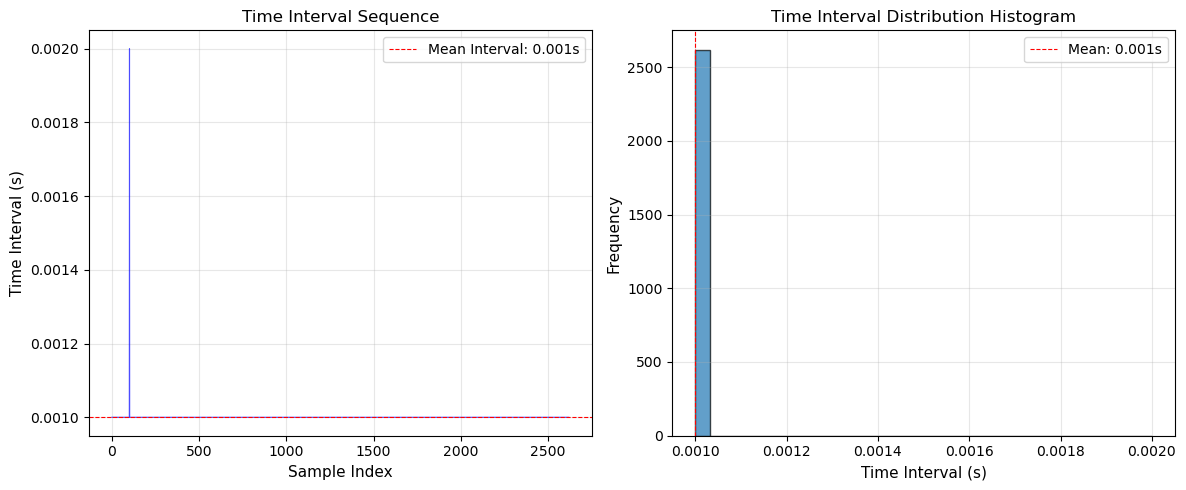


原始采样率 fs_raw ≈ 999.62 Hz  (CV=0.020)


In [18]:
from ble_analysis.diagnostics import analyze_time_intervals

time_info = analyze_time_intervals(
    timestamps_ms,
    plot=True,
    save_path=FIGURES_DIR / f"dip_ch{channel}_time_intervals.png",
    verbose=True,
)

fs_raw = time_info["estimated_sampling_rate"]
cv = time_info.get("cv", float("nan"))
print(f"\n原始采样率 fs_raw ≈ {fs_raw:.2f} Hz  (CV={cv:.3f})")

## 5. 可选：重采样到均匀 20 Hz 网格

当原始 fs 很高（如 ~1000 Hz）而呼吸带通只需 0.1–0.35 Hz 时，直接在原始率上滤波虽然可行，
但 median/hampel 的 `window_size` 会按**样本数**理解（3 点 = 3 ms @ 1000 Hz）。

若希望与 CS 脚本相同的「3 点 ≈ 150 ms」语义，可先 `resample_to_uniform_grid(..., target_fs=20)`。

In [6]:
from ble_analysis.resampling import resample_to_uniform_grid

if use_decimate_to_20hz:
    rs_amp = resample_to_uniform_grid(time_sec, local_amp, target_fs=target_fs)
    rs_phase = resample_to_uniform_grid(time_sec, local_phase, target_fs=target_fs)
    t = rs_amp["time_sec"]
    signal_work = rs_amp["values"]
    phase_work = rs_phase["values"]
    fs = target_fs
    print(f"已重采样: {len(local_amp)} 点 @ {fs_raw:.1f} Hz → {len(signal_work)} 点 @ {fs} Hz")
else:
    t = time_sec
    signal_work = local_amp.copy()
    phase_work = local_phase.copy()
    fs = fs_raw
    print(f"跳过重采样，在原始 fs={fs:.2f} Hz 上滤波")

已重采样: 2621 点 @ 1000.0 Hz → 53 点 @ 20.0 Hz


## 6. 滤波 pipeline

`apply_filter_pipeline` 按顺序执行各步骤，内部封装 `utils.signal_algrithom`：

1. **median** — 平滑短脉冲
2. **hampel** — 剔除离群点
3. **highpass** — 去低频漂移（cutoff 单位 Hz，与 fs 无关）
4. **bandpass** — 呼吸频段 0.1–0.35 Hz（成人静息）

可根据实验调整 `window_size`、cutoff；修改 fs 后只需保证 Nyquist > highcut。

In [7]:
from ble_analysis.filters import apply_filter_pipeline

# 呼吸分析常用 pipeline（与 glb_cs 系列一致）
breath_pipeline = [
    {"type": "median", "window_size": 3},
    {"type": "hampel", "window_size": 3, "n_sigma": 3},
    {"type": "highpass", "cutoff": 0.05, "order": 1},
    {"type": "bandpass", "lowcut": 0.1, "highcut": 0.35, "order": 2},
]

# 相位通常不做带通，只做去趋势前的平滑
phase_pipeline = [
    {"type": "median", "window_size": 3},
    {"type": "hampel", "window_size": 3, "n_sigma": 3},
    {"type": "highpass", "cutoff": 0.05, "order": 1},
]

filtered_amp = apply_filter_pipeline(signal_work, fs=fs, pipeline=breath_pipeline)
filtered_phase = apply_filter_pipeline(phase_work, fs=fs, pipeline=phase_pipeline)

print(f"滤波完成: {len(filtered_amp)} 点, fs={fs} Hz")

滤波完成: 53 点, fs=20.0 Hz


## 7. 可视化

对比 raw 与 filtered 的 local amplitude / phase。

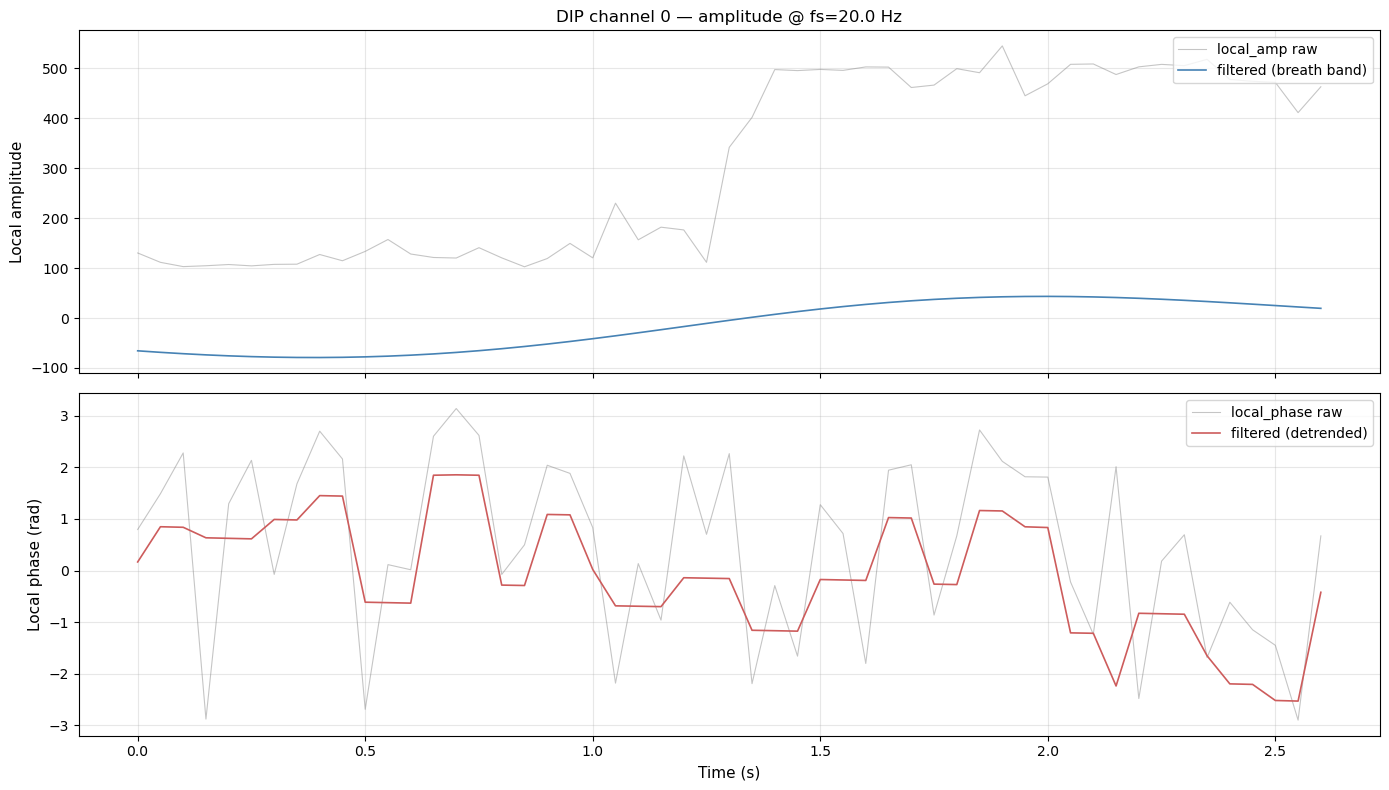

已保存: D:\Work\atomic\ble_hci_sensing\outputs\figures\dip_ch0_filtered.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(t, signal_work, color="gray", alpha=0.45, linewidth=0.8, label="local_amp raw")
axes[0].plot(t, filtered_amp, color="steelblue", linewidth=1.2, label="filtered (breath band)")
axes[0].set_ylabel("Local amplitude")
axes[0].set_title(f"DIP channel {channel} — amplitude @ fs={fs:.1f} Hz")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, phase_work, color="gray", alpha=0.45, linewidth=0.8, label="local_phase raw")
axes[1].plot(t, filtered_phase, color="indianred", linewidth=1.2, label="filtered (detrended)")
axes[1].set_ylabel("Local phase (rad)")
axes[1].set_xlabel("Time (s)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out_png = FIGURES_DIR / f"dip_ch{channel}_filtered.png"
fig.savefig(out_png, dpi=150)
plt.show()
print(f"已保存: {out_png}")

## 8. （可选）一键探索 API

若只需快速查看单通道统计与时间诊断，也可直接调用 `run_cs_exploration`——
它对 DIP 同样适用（函数名保留 CS 是历史原因）。

In [14]:
from ble_analysis.workflow import run_cs_exploration

# verbose=False 避免重复打印；save_figures 会写到 FIGURES_DIR
quick = run_cs_exploration(
    filepath,
    channel,
    figures_dir=FIGURES_DIR,
    verbose=False,
    save_figures=True,
    show_plots=False,
)

print(f"一键探索 → fs≈{quick['actual_sampling_rate']:.2f} Hz, 点数={len(quick['series']['local_amplitudes'])}")

✓ DIP_frames_all_20260519_165725.jsonl | v3.6.0 | 2621 frames | span 3s | saved 2026-05-19T16:57:25 | ch0: 2621 pts | fs≈1000.00 Hz | CV=0.000 (均匀) → figures/channel_0_*.png
一键探索 → fs≈1000.00 Hz, 点数=2621


## 后续步骤

- 若要做 **分段 BPM / IE / apnea 指标**，可参考 `glb_cs_segment_breath_analysis.ipynb`，
  将 `segment_variables` 设为 `["local_amplitudes"]`，并确保 `fs` 与重采样策略一致。
- 全量多通道滤波算法步骤见 `glb_cs_full_pipeline_demo.ipynb`（冻结参考，不维护）。
- 更多 API 说明见 [`src/ble_analysis/README.md`](../src/ble_analysis/README.md)。